# Stroke Prediction: Traditional ML vs Deep Learning
## Summative Project: Introduction to Machine Learning

---

**Problem Statement**  
Stroke ranks as the second most common cause of mortality in the world (WHO, 2023). The early detection of patients who are at risk facilitates the provision of medical care and significantly lowers their disability and mortality rates. This research focuses on developing machine learning models for predicting stroke using various health parameters of patients. Mostly designed to help healthcare Institutions and governments to make policy decisions backed by trusted data.

**Dataset**  
Kaggle – *Stroke Prediction Dataset* by fedesoriano (2021)  
🔗 https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
- **5,110 patients** × 11 clinical/lifestyle features  
- Binary target: `stroke` (1 = had stroke, 0 = no stroke)

**Pipeline Overview**

| Section | Content |
|---------|---------|
| 1 | Imports & Setup |
| 2 | Data Loading |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Preprocessing & Feature Engineering |
| 5 | Traditional ML (Scikit-learn) |
| 6 | Deep Learning using Sequential API |
| 7 | Deep Learning using Functional API (Wide & Deep) |
| 8 | Deep Learning using tf.data API Pipeline |
| 9 | Results Comparison & Visualisation |
| 10 | Key Findings & Healthcare Implications |

---


## Section 1: Imports & Configuration

We begin by installing required packages and setting global configuration. All random seeds are fixed for reproducibility.

In [2]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.impute             import SimpleImputer
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm                import SVC
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras           import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Global configuration
SEED       = 42
TEST_SIZE  = 0.20

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully")
print(f"TensorFlow version : {tf.__version__}")
print(f"Random seed        : {SEED}")

All libraries imported successfully
TensorFlow version : 2.20.0
Random seed        : 42


## Section 2: Data Loading

The dataset is downloaded directly from Kaggle using `kagglehub`. It contains **5,110 patient records** with 11 features including age, hypertension status, heart disease history, glucose levels, BMI, and smoking status.

In [3]:
import kagglehub, os

#1-Download dataset
dataset_root_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

#2-Define the name of the CSV file within the dataset
csv_file_name = "healthcare-dataset-stroke-data.csv"

#3-the full path to the CSV file
full_csv_path = os.path.join(dataset_root_path, csv_file_name)

#4-Load dataset
stroke_df = pd.read_csv(full_csv_path)

print()
print(f"Dataset '{csv_file_name}' loaded successfully from: {full_csv_path}")
print(f"Shape of Stroke prediction dataset: {stroke_df.shape}")

100%|██████████| 67.4k/67.4k [00:00<00:00, 32.9MB/s]

Extracting files...

Dataset 'healthcare-dataset-stroke-data.csv' loaded successfully from: /root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1/healthcare-dataset-stroke-data.csv
Shape of Stroke prediction dataset: (5110, 12)


In [4]:
#displaying first 5 rows
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Check data types and missing values
print("Data Types")
print("======================================")
print(stroke_df.dtypes)
print()
print("Missing Values")
print("======================================")
print(stroke_df.isnull().sum())
print()
print("Target Distribution")
print("======================================")
counts = stroke_df["stroke"].value_counts()
print(counts)
print(f"\nStroke prevalence: {stroke_df['stroke'].mean()*100:.2f}%")

Data Types
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Target Distribution
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke prevalence: 4.87%


*As visible in The target distribution, It is highly imbalanced, we will solve this with SMOTE in pre-processing.*

In [6]:
# Dropping Id columns as it's not that important
stroke_df.drop("id", axis=1, inplace=True)

In [7]:
# Summary statistics for numeric columns
stroke_df.describe().round(2)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,43.23,0.1,0.05,106.15,28.89,0.05
std,22.61,0.3,0.23,45.28,7.85,0.22
min,0.08,0.0,0.00,55.12,10.30,0.00
25%,25.00,0.0,0.00,77.24,23.50,0.00
50%,45.00,0.0,0.00,91.88,28.10,0.00
75%,61.00,0.0,0.00,114.09,33.10,0.00
max,82.00,1.0,1.00,271.74,97.60,1.00


## Section 3:  Exploratory Data Analysis (EDA)

Before modelling, we explore the data visually to understand feature distributions, relationships with stroke outcome, and potential data quality issues.

Key questions we answer here:
- How does age differ between stroke and non-stroke patients?
- Do clinical risk factors (hypertension, heart disease, glucose) correlate with stroke?
- Are there demographic patterns (gender, work type, residence)?


Text(0.5, 1.0, 'Feature Correlation Map')

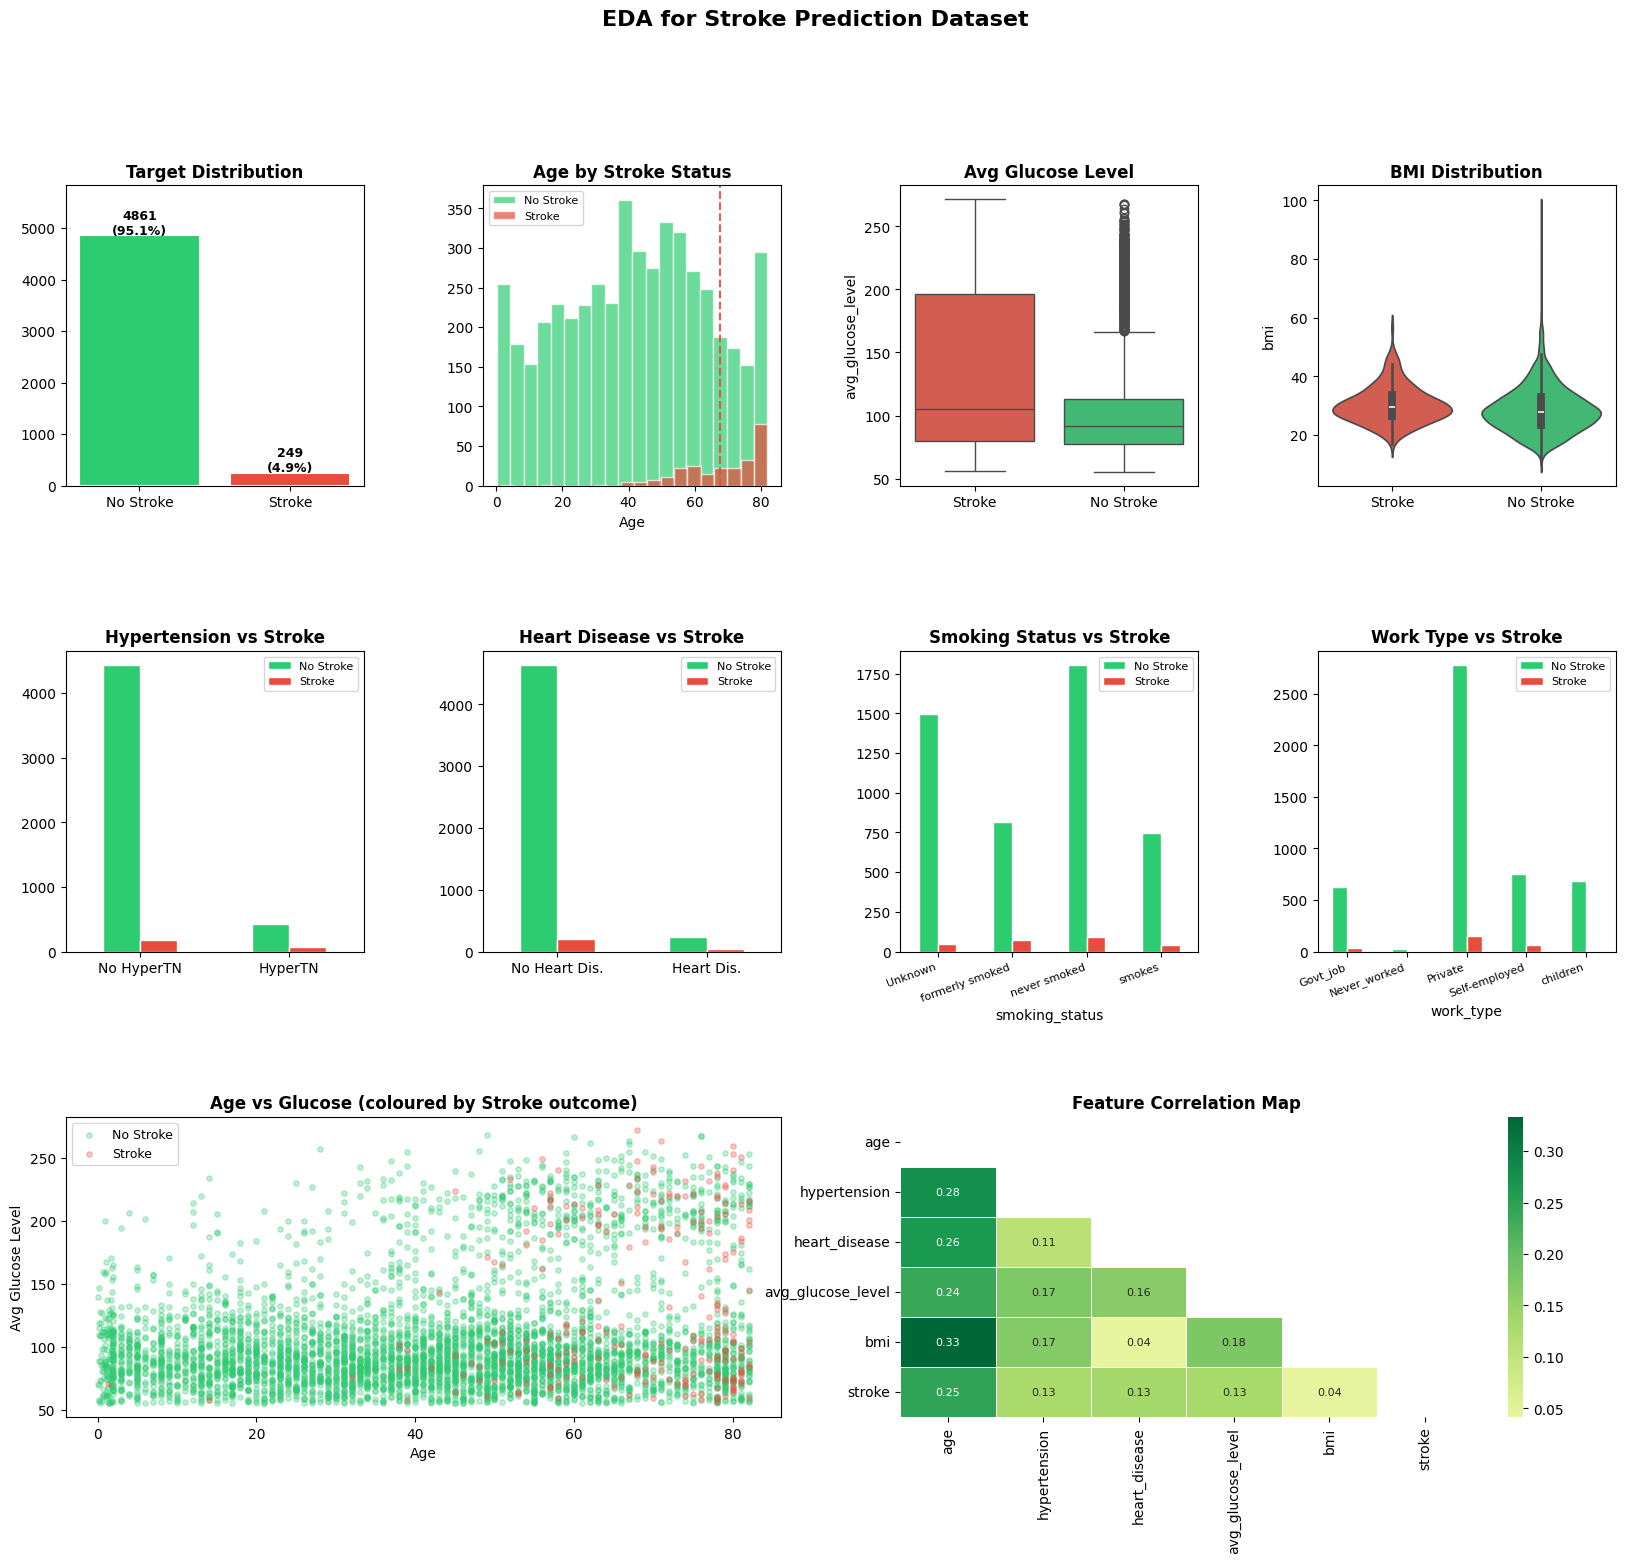

In [8]:
#Add readable label for plotting (0:No stroke, 1: Stroke)
stroke_df["stroke_label"] = stroke_df["stroke"].map({0: "No Stroke", 1: "Stroke"})
pal = {0: "#2ecc71", 1: "#e74c3c"}

fig = plt.figure(figsize=(20, 16))
fig.suptitle("EDA for Stroke Prediction Dataset",
             fontsize=16, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)


#Target distribution
ax = fig.add_subplot(gs[0, 0])
counts = stroke_df["stroke"].value_counts()
bars = ax.bar(["No Stroke", "Stroke"], counts.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
            f"{v}\n({v/len(stroke_df):.1%})", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Target Distribution", fontweight="bold")
ax.set_ylim(0, max(counts.values)*1.2)


#Age by stroke status
ax = fig.add_subplot(gs[0, 1])
for t, c in pal.items():
    sub = stroke_df[stroke_df["stroke"] == t]["age"]
    ax.hist(sub, bins=20, alpha=0.7, color=c,
            label=["No Stroke","Stroke"][t], edgecolor="white")
ax.axvline(stroke_df[stroke_df["stroke"]==1]["age"].mean(), color="#e74c3c", ls="--", alpha=0.9)
ax.set_title("Age by Stroke Status", fontweight="bold")
ax.set_xlabel("Age"); ax.legend(fontsize=8)


#Avg glucose level
ax = fig.add_subplot(gs[0, 2])
sns.boxplot(data=stroke_df, x="stroke_label", y="avg_glucose_level",
            palette={"No Stroke":"#2ecc71","Stroke":"#e74c3c"}, ax=ax)
ax.set_title("Avg Glucose Level", fontweight="bold"); ax.set_xlabel("")


#BMI violin plot
ax = fig.add_subplot(gs[0, 3])
sns.violinplot(data=stroke_df, x="stroke_label", y="bmi",
               palette={"No Stroke":"#2ecc71","Stroke":"#e74c3c"}, ax=ax)
ax.set_title("BMI Distribution", fontweight="bold"); ax.set_xlabel("")


#Hypertension plot
ax = fig.add_subplot(gs[1, 0])
ht = stroke_df.groupby(["hypertension","stroke"]).size().unstack(fill_value=0)
ht.index = ["No HyperTN","HyperTN"]
ht.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c"], edgecolor="white", legend=False)
ax.set_title("Hypertension vs Stroke", fontweight="bold")
ax.set_xticklabels(["No HyperTN","HyperTN"], rotation=0)
ax.legend(["No Stroke","Stroke"], fontsize=8)


#Heart disease plot
ax = fig.add_subplot(gs[1, 1])
hd = stroke_df.groupby(["heart_disease","stroke"]).size().unstack(fill_value=0)
hd.index = ["No HD","Heart Dis."]
hd.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c"], edgecolor="white", legend=False)
ax.set_title("Heart Disease vs Stroke", fontweight="bold")
ax.set_xticklabels(["No Heart Dis.","Heart Dis."], rotation=0)
ax.legend(["No Stroke","Stroke"], fontsize=8)


#Smoking status plot
ax = fig.add_subplot(gs[1, 2])
smoke_ct = stroke_df.groupby(["smoking_status","stroke"]).size().unstack(fill_value=0)
smoke_ct.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c"], edgecolor="white", legend=False)
ax.set_title("Smoking Status vs Stroke", fontweight="bold")
ax.set_xticklabels(smoke_ct.index, rotation=20, ha="right", fontsize=8)
ax.legend(["No Stroke","Stroke"], fontsize=8)


#Work type plot
ax = fig.add_subplot(gs[1, 3])
wt_ct = stroke_df.groupby(["work_type","stroke"]).size().unstack(fill_value=0)
wt_ct.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c"], edgecolor="white", legend=False)
ax.set_title("Work Type vs Stroke", fontweight="bold")
ax.set_xticklabels(wt_ct.index, rotation=20, ha="right", fontsize=8)
ax.legend(["No Stroke","Stroke"], fontsize=8)


#Age vs Glucose scatter plot
ax = fig.add_subplot(gs[2, 0:2])
for t, c in pal.items():
    sub = stroke_df[stroke_df["stroke"]==t]
    ax.scatter(sub["age"], sub["avg_glucose_level"], c=c, alpha=0.3, s=15,
               label=["No Stroke","Stroke"][t])
ax.set_xlabel("Age"); ax.set_ylabel("Avg Glucose Level")
ax.set_title("Age vs Glucose (coloured by Stroke outcome)", fontweight="bold")
ax.legend(fontsize=9)


#Correlation heatmap
ax = fig.add_subplot(gs[2, 2:])
num_cols = stroke_df.select_dtypes(include=np.number).drop(
    columns=["stroke"], errors="ignore").columns
corr = stroke_df[list(num_cols)+["stroke"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, annot_kws={"size":8}, linewidths=0.5)
ax.set_title("Feature Correlation Map", fontweight="bold")

### Observations From EDA

- **Age** is the strongest individual predictor; stroke patients are on average ~15 years older  
- **Glucose levels** are considerably higher in stroke patients (diabetic range)  
- **Hypertension** and **heart disease** nearly double stroke risk  
- **Class imbalance** is severe; only ~4.9% of patients had a stroke. Without correction, any model will simply predict "No Stroke" for everyone and achieve 95% accuracy while being medically useless  
- **Smoking status** shows a significant proportion as "Unknown" which is a data quality issue to address in preprocessing


## Section 4: Preprocessing & Feature Engineering

This section prepares the data for modelling through four key steps:

1. **Categorical encoding:** converting text columns to numeric values.
2. **Missing value imputation:** fill missing BMI values with the median.  
3. **Feature engineering:** create new features that capture clinical domain knowledge  
4. **SMOTE oversampling:** balancing the minority class (stroke = 1) on the *training set only* synthetically to avoid data leakage

In [9]:
#Remove the helper label column we used for plotting
df = stroke_df.drop("stroke_label", axis=1, errors="ignore")

#Step 1: Encode categorical columns
categ_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode: {categ_cols}")

le = LabelEncoder()
for col in categ_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col}: encoded -> {sorted(df[col].unique())}")

print("\nEncoding completed successfully...")

Categorical columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
  gender: encoded -> [np.int64(0), np.int64(1), np.int64(2)]
  ever_married: encoded -> [np.int64(0), np.int64(1)]
  work_type: encoded -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Residence_type: encoded -> [np.int64(0), np.int64(1)]
  smoking_status: encoded -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Encoding completed successfully...


In [10]:
#Step 2: Feature Engineering
"""
Clinical domain knowledge:
  age × glucose: captures combined metabolic + age risk
  age × bmi    : obesity impact deteriorates with age
  risk_score   : mixture of 4 established binary stroke risk factors
"""

df["age_glucose"] = df["age"] * df["avg_glucose_level"]
# The missing values in bmi, we fill them with median
df["age_bmi"]     = df["age"] * df["bmi"].fillna(df["bmi"].median())
df["risk_score"]  = (
    df["hypertension"] +
    df["heart_disease"] +
    (df["age"] > 65).astype(int) +
    (df["avg_glucose_level"] > 140).astype(int)
)

print("Feature engineering completed successfully...")
print(f"   New features: age_glucose, age_bmi, risk_score")
print(f"   Final feature count: {df.shape[1] - 1}")
print()
df[["age","avg_glucose_level","age_glucose","risk_score","stroke"]].head(6)

Feature engineering completed successfully...
   New features: age_glucose, age_bmi, risk_score
   Final feature count: 13



,age,avg_glucose_level,age_glucose,risk_score,stroke
0,67.0,228.69,15322.23,3,1
1,61.0,202.21,12334.81,1,1
2,80.0,105.92,8473.60,2,1
3,49.0,171.23,8390.27,1,1
4,79.0,174.12,13755.48,3,1
5,81.0,186.21,15083.01,2,1


In [11]:
#Step 3: Splitting & Imputations
feature_names = [col for col in df.columns if col != "stroke"]
X = df[feature_names].values
y = df["stroke"].values

#Imputing missing BMI values (median strategy)
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

#stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples | {y_train.mean()*100:.2f}% stroke")
print(f"Test set     : {X_test.shape[0]} samples  | {y_test.mean()*100:.2f}% stroke")

Training set : 4088 samples | 4.87% stroke
Test set     : 1022 samples  | 4.89% stroke


In [13]:
#Step 4:SMOTE oversampling (target variable - on train set)
smote = SMOTE(random_state=SEED, sampling_strategy = 0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Stroke=0: {(y_train==0).sum()}  |  Stroke=1: {(y_train==1).sum()}")
print()
print("After SMOTE:")
print(f"  Stroke=0: {(y_train_sm==0).sum()}  |  Stroke=1: {(y_train_sm==1).sum()}")
print(f"  New balance: {y_train_sm.mean()*100:.1f}% positive")
print()
print("SMOTE applied successfully on train set.")

Before SMOTE:
  Stroke=0: 3889  |  Stroke=1: 199

After SMOTE:
  Stroke=0: 3889  |  Stroke=1: 1166
  New balance: 23.1% positive

SMOTE applied successfully on train set.


In [14]:
#Step 5: Scale features
#normalises features to mean=0, std=1
# Fit ONLY on training data, then transform both train and test

scaler = StandardScaler()
#scaled Smote balanced on train set
X_train_sc = scaler.fit_transform(X_train_sm)
#scaling the test set
X_test_sc  = scaler.transform(X_test)

print(f"Scaling completed successfully...")
print(f"   Training matrix : {X_train_sc.shape}")
print(f"   Test matrix     : {X_test_sc.shape}")

Scaling completed successfully...
   Training matrix : (5055, 13)
   Test matrix     : (1022, 13)


## Section 5: Traditional Machine Learning (Scikit-learn)

We train four classical ML models using Scikit-learn:

| Model | Why it's included |
|-------|-------------------|
| **Logistic Regression** | Interpretable linear baseline; widely used in clinical risk scores |
| **Random Forest** | Ensemble of decision trees; handles non-linearity, gives feature importances |
| **Gradient Boosting** | Sequential boosting; often top performer on tabular data |
| **SVM (RBF kernel)** | Strong in high-dimensional, small-to-medium datasets |

Each model uses an **imbalanced-learn pipeline** that applies SMOTE, scale, then train inside each cross-validation fold, to prevent any data leakage.

We also use **5-fold stratified cross-validation** on the training set to get reliable AUC estimates, then report final metrics on the held-out test set.


In [15]:
#Cross-validation
c_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SMOTE_STRATEGY = 0.3

#Define imbalanced pipelines: SMOTE + scale + model, inside the pipeline
trad_pipelines = {
    "Logistic Regression": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED, sampling_strategy=SMOTE_STRATEGY)),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
                       max_iter=2000,
                       C=0.5,
                       class_weight="balanced",
                       solver="lbfgs",
                       random_state=SEED))
    ]),

    "Random Forest": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED, sampling_strategy=SMOTE_STRATEGY)),
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(
                       n_estimators=300,
                       max_depth=12,
                       class_weight="balanced",
                       min_samples_leaf=2,
                       random_state=SEED))
    ]),

    "Gradient Boosting": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED, sampling_strategy=SMOTE_STRATEGY)),
        ("scaler", StandardScaler()),
        ("clf",    GradientBoostingClassifier(
                       n_estimators=300,
                       learning_rate=0.05,
                       max_depth=4,
                       subsample=0.8,
                       min_samples_leaf=4,
                       random_state=SEED))
    ]),

    "SVM (RBF)": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED, sampling_strategy=SMOTE_STRATEGY)),
        ("scaler", StandardScaler()),
        ("clf",    SVC(
                       kernel="rbf",
                       C=1.0,
                       probability=True,
                       class_weight="balanced",
                       random_state=SEED))
    ]),
}
print(f"\n{len(trad_pipelines)} pipelines defined successfully..")
print(f"CV strategy : StratifiedKFold(n_splits=5)")
print(f"Each fold   : SMOTE -> Scale -> Train -> Validation")


4 pipelines defined successfully..
CV strategy : StratifiedKFold(n_splits=5)
Each fold   : SMOTE -> Scale -> Train -> Validation


In [16]:
#Lowered to improve recall for stroke detection
THRESHOLD = 0.3

trad_results = {}

for name, model in trad_pipelines.items():
    print(f"\n{'-'*50}")
    print(f"Training: {name}")

    #Step 1: 5-fold stratified cross-validation (cv defined in cell above)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=c_val, scoring="roc_auc", n_jobs=-1
    )
    print(f"  CV AUC per fold : {[round(s, 3) for s in cv_scores]}")
    print(f"  CV AUC mean±std : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    #Step 2: Fit on full training set
    model.fit(X_train, y_train)

    #Step 3: Find optimal threshold from training predictions
    train_proba = model.predict_proba(X_train)[:, 1]
    thresholds  = np.linspace(0.05, 0.60, 100)
    f1_scores   = [f1_score(y_train,
                            (train_proba >= t).astype(int),
                            zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"  Optimal threshold (max F1 on train): {best_threshold:.2f}")

    #Step 4: Evaluate on test set using optimal threshold
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= best_threshold).astype(int)

    trad_results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "y_proba":   y_proba,
        "threshold": best_threshold,
        "CV_AUC":    cv_scores.mean(),
        "CV_AUC_std":cv_scores.std(),
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred),
        "AUC":       roc_auc_score(y_test, y_proba),
        "PR_AUC":    average_precision_score(y_test, y_proba),
    }
    r = trad_results[name]
    total_pos = (y_test == 1).sum()
    tp = int(r['Recall'] * total_pos)
    print(f"  Test AUC       : {r['AUC']:.3f}")
    print(f"  Recall         : {r['Recall']:.3f}  ({tp}/{total_pos} stroke cases caught)")
    print(f"  Precision      : {r['Precision']:.3f}")
    print(f"  F1             : {r['F1']:.3f}")


--------------------------------------------------
Training: Logistic Regression
  CV AUC per fold : [np.float64(0.822), np.float64(0.857), np.float64(0.823), np.float64(0.822), np.float64(0.858)]
  CV AUC mean±std : 0.836 ± 0.017
  Optimal threshold (max F1 on train): 0.59
  Test AUC       : 0.839
  Recall         : 0.780  (39/50 stroke cases caught)
  Precision      : 0.177
  F1             : 0.289

--------------------------------------------------
Training: Random Forest
  CV AUC per fold : [np.float64(0.821), np.float64(0.835), np.float64(0.806), np.float64(0.801), np.float64(0.811)]
  CV AUC mean±std : 0.815 ± 0.012
  Optimal threshold (max F1 on train): 0.46
  Test AUC       : 0.801
  Recall         : 0.140  (7/50 stroke cases caught)
  Precision      : 0.184
  F1             : 0.159

--------------------------------------------------
Training: Gradient Boosting
  CV AUC per fold : [np.float64(0.831), np.float64(0.832), np.float64(0.8), np.float64(0.839), np.float64(0.801)]
  C

In [20]:
#detailed classification report for best traditional model
best_trad = max(trad_results, key=lambda k: trad_results[k]["AUC"])
print(f"Detailed classification report\n")
print(f"Best model: {best_trad}")
print('---------------------------------')
print(classification_report(y_test, trad_results[best_trad]["y_pred"],
                            target_names=["No Stroke", "Stroke"]))

Detailed classification report

Best model: Logistic Regression
---------------------------------
              precision    recall  f1-score   support

   No Stroke       0.99      0.81      0.89       972
      Stroke       0.18      0.78      0.29        50

    accuracy                           0.81      1022
   macro avg       0.58      0.80      0.59      1022
weighted avg       0.95      0.81      0.86      1022



## Section 6: Deep Learning: Sequential API

The **Sequential API** builds a neural network layer-by-layer in a linear stack. This is the simplest and most readable way to define a feedforward DNN in Keras.

**Architecture:**
```
Input (13 features)
  * Dense(128, ReLU) -> BatchNorm -> Dropout(0.35)
  * Dense(64,  ReLU) -> BatchNorm -> Dropout(0.30)
  * Dense(32,  ReLU) -> BatchNorm -> Dropout(0.20)
  * Dense(1, Sigmoid) :  probability of stroke
```

**Design choices:**
- `BatchNormalization`: stabilises training by normalising layer activations
- `Dropout`: regularises the network to reduce overfitting
- `EarlyStopping`: stops training when validation AUC stops improving (saves best weights)
- `ReduceLROnPlateau`: halves learning rate when loss plateaus


In [29]:
INPUT_DM = X_train_sc.shape[1]
print(f"Input dimension: {INPUT_DM} features")

def make_callbacks(monitor="val_auc", patience=30):
    """Reusable callbacks for all DNN experiments."""
    return [
        EarlyStopping(patience=patience, restore_best_weights=True,
                      monitor=monitor, mode="max",
                      min_delta=0.001,
                      verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=20, min_lr=1e-6,
                          monitor="val_loss", verbose=1)
    ]
def build_sequential(input_dim, dropout=0.35):
    """Build a regularised feedforward DNN using the Sequential API."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dropout(dropout - 0.05),

        layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(1, activation="sigmoid")
    ], name="Sequential_DNN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=["accuracy",
                keras.metrics.AUC(name="auc"),
                keras.metrics.Recall(name="recall")]
    )
    return model

sequential_model = build_sequential(INPUT_DM)
sequential_model.summary()

Input dimension: 13 features


Model: "Sequential_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
#Train the Sequential DNN
print("Training Sequential DNN ...")
sequential_hist = sequential_model.fit(
    X_train_sc, y_train_sm,
    epochs=300,
    batch_size=128,
    validation_split=0.20,
    callbacks=make_callbacks(),
    class_weight={0: 1.0, 1: 5.0},
    verbose=0
)
print(f"\nTraining complete, stopped at epoch {len(sequential_hist.history['loss'])}")

Training Sequential DNN ...

Epoch 30: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 50: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 70: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 90: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 110: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
Epoch 129: early stopping
Restoring model weights from the end of the best epoch: 99.

Training complete, stopped at epoch 129


In [32]:
# Evaluate on test set with per-model optimal threshold
yp_seq = sequential_model.predict(X_test_sc, verbose=0).ravel()

# Find optimal threshold on training predictions
train_proba_seq = sequential_model.predict(X_train_sc, verbose=0).ravel()
thresholds = np.linspace(0.05, 0.80, 100)
f1s = [f1_score(y_train_sm, (train_proba_seq >= t).astype(int), zero_division=0)
       for t in thresholds]
best_t_seq = thresholds[np.argmax(f1s)]
print(f"Optimal threshold (max F1 on train): {best_t_seq:.2f}")

ypred_seq = (yp_seq >= best_t_seq).astype(int)

seq_result = {
    "y_pred": ypred_seq, "y_proba": yp_seq,
    "threshold": best_t_seq,
    "Accuracy":  accuracy_score(y_test, ypred_seq),
    "F1":        f1_score(y_test, ypred_seq, zero_division=0),
    "Precision": precision_score(y_test, ypred_seq, zero_division=0),
    "Recall":    recall_score(y_test, ypred_seq),
    "AUC":       roc_auc_score(y_test, yp_seq),
    "PR_AUC":    average_precision_score(y_test, yp_seq),
}
total_pos = (y_test == 1).sum()
tp = int(seq_result['Recall'] * total_pos)
print(f"Sequential DNN @ threshold={best_t_seq:.2f}:")
print(f"  AUC       : {seq_result['AUC']:.3f}")
print(f"  Recall    : {seq_result['Recall']:.3f}  ({tp}/{total_pos} stroke cases caught)")
print(f"  Precision : {seq_result['Precision']:.3f}")
print(f"  F1        : {seq_result['F1']:.3f}")

Optimal threshold (max F1 on train): 0.38
Sequential DNN @ threshold=0.38:
  AUC       : 0.787
  Recall    : 0.700  (35/50 stroke cases caught)
  Precision : 0.148
  F1        : 0.244


## Section 7: Deep Learning - Functional API

The **Functional API** allows building non-linear architectures where layers can have multiple inputs, outputs, and skip connections. WE use it because it's impossible with the Sequential API.

We implement the **Wide & Deep** architecture, which combines:
- **Deep path**: stacked layers that learn complex non-linear feature interactions
- **Wide path**: a direct connection from raw input to the merge layer, which helps the model "remember" original feature values

```
                Input
               /     \
           Deep        Wide
        28->64->32    Dense(32)
               \     /
             Concatenate
              Dense(32)
          Dense(1, Sigmoid)
```

This works especially well for stroke prediction due to the presence of features such as age and hypertension which have a high degree of influence on stroke that would be distorted by the deep network.


In [33]:
def build_wide_and_deep(input_dim):
    """
    Wide & Deep architecture using the Functional API.
    Deep path  : learns complex feature interactions
    Wide path  : preserves direct linear signals from raw features
    """
    inp = Input(shape=(input_dim,), name="input")

    #Deep path
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal",
                     name="deep_1")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu", kernel_initializer="he_normal",
                     name="deep_2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu", kernel_initializer="he_normal",
                     name="deep_3")(x)

    #Wide path (skip connection from raw input)
    wide = layers.Dense(32, activation="relu", kernel_initializer="he_normal",
                        name="wide")(inp)

    #Merge and output
    merged = layers.concatenate([x, wide], name="merge")
    merged = layers.Dense(32, activation="relu", name="merge_dense")(merged)
    merged = layers.Dropout(0.20)(merged)
    output    = layers.Dense(1, activation="sigmoid", name="output")(merged)

    model = Model(inputs=inp, outputs=output, name="WideAndDeep_DNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

func_model = build_wide_and_deep(INPUT_DM)
func_model.summary()

Model: "WideAndDeep_DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 13)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_1 (Dense)      │ (None, 128)       │      1,792 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ deep_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_2 (Dense)      │ (None, 64)        │      8,256 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ deep_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_3 (Dense)      │ (None, 32)        │      2,080 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide (Dense)        │ (None, 32)        │        448 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 64)        │          0 │ deep_3[0][0],     │
│                     │                   │            │ wide[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_dense (Dense) │ (None, 32)        │      2,080 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ merge_dense[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,457 (60.38 KB)

 Trainable params: 15,073 (58.88 KB)

 Non-trainable params: 384 (1.50 KB)

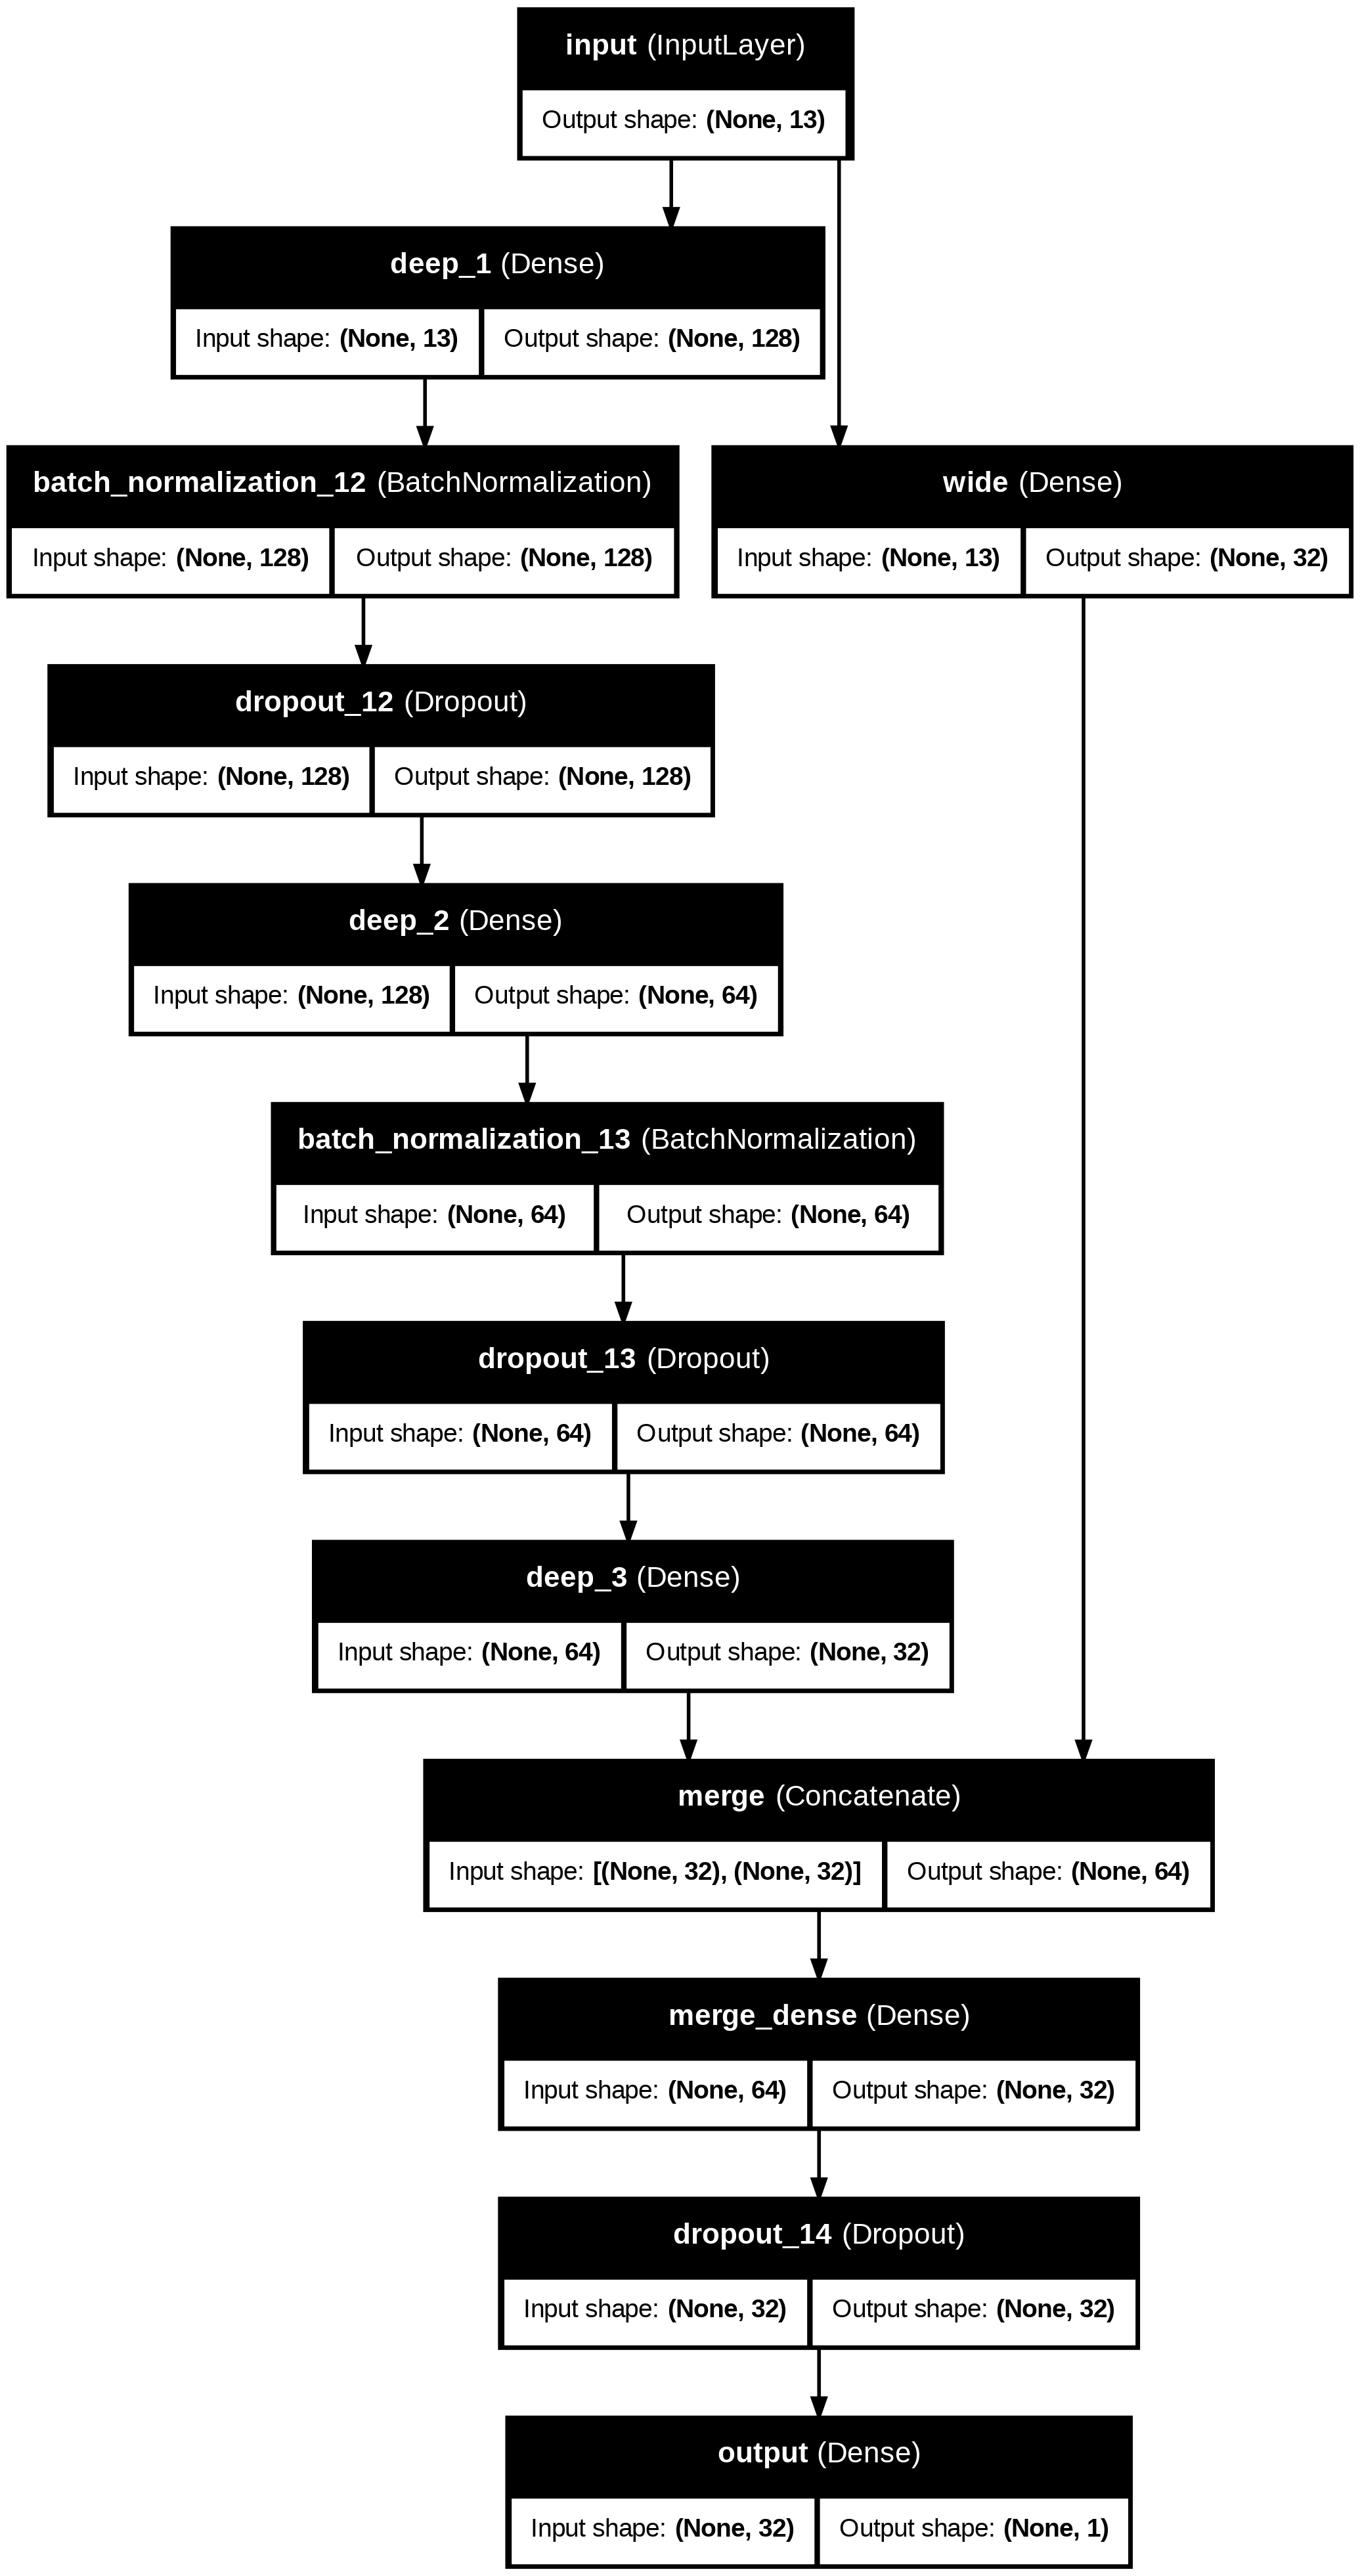

In [41]:
#Visualise the model graph
keras.utils.plot_model(func_model, show_shapes=True,
                       show_layer_names=True, rankdir="TB")

In [44]:
# Train The Functional Model (Wide & Deep)
h_func = func_model.fit(
    X_train_sc, y_train_sm,
    epochs=300,
    batch_size=128,
    validation_split=0.20,
    callbacks=make_callbacks(),
    class_weight={0: 1.0, 1: 3.0},
    verbose=0
)


Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 61: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 65: early stopping
Restoring model weights from the end of the best epoch: 35.


In [45]:
# Evaluate Wide & Deep DNN on test set with per-model optimal threshold
yp_func = func_model.predict(X_test_sc, verbose=0).ravel()

# Find optimal threshold on training predictions
train_proba_func = func_model.predict(X_train_sc, verbose=0).ravel()
thresholds = np.linspace(0.05, 0.80, 100)
f1s = [f1_score(y_train_sm, (train_proba_func >= t).astype(int), zero_division=0)
       for t in thresholds]
best_t_func = thresholds[np.argmax(f1s)]
print(f"Optimal threshold (max F1 on train): {best_t_func:.2f}")

ypred_func = (yp_func >= best_t_func).astype(int)

func_result = {
    "y_pred": ypred_func, "y_proba": yp_func,
    "threshold": best_t_func,
    "Accuracy":  accuracy_score(y_test, ypred_func),
    "F1":        f1_score(y_test, ypred_func, zero_division=0),
    "Precision": precision_score(y_test, ypred_func, zero_division=0),
    "Recall":    recall_score(y_test, ypred_func),
    "AUC":       roc_auc_score(y_test, yp_func),
    "PR_AUC":    average_precision_score(y_test, yp_func),
}
total_pos = (y_test == 1).sum()
tp = int(func_result['Recall'] * total_pos)
print(f"Wide & Deep DNN : threshold={best_t_func:.2f}:")
print(f"  AUC       : {func_result['AUC']:.3f}")
print(f"  Recall    : {func_result['Recall']:.3f}  ({tp}/{total_pos} stroke cases caught)")
print(f"  Precision : {func_result['Precision']:.3f}")
print(f"  F1        : {func_result['F1']:.3f}")

Optimal threshold (max F1 on train): 0.28
Wide & Deep DNN : threshold=0.28:
  AUC       : 0.828
  Recall    : 0.620  (31/50 stroke cases caught)
  Precision : 0.187
  F1        : 0.287


## Section 8: Deep Learning: tf.data API Pipeline

The **`tf.data` API** is TensorFlow's recommended way to build scalable, efficient data input pipelines. Rather than loading all data into memory at once, it streams data using:

- `from_tensor_slices`: creates a dataset from in-memory arrays  
- `shuffle`: randomly reorders samples each epoch to prevent ordering bias  
- `map`: applies preprocessing functions lazily
- `batch`: groups samples into mini-batches  
- `prefetch(AUTOTUNE)`: overlaps data loading with model training (here CPU prepares next batch while GPU trains on current batch)


In [46]:
BATCH_SIZE = 64

def make_tf_dataset(X, y, shuffle=True):
    """
    Build a performant tf.data pipeline.

    Args:
        X       : NumPy feature array
        y       : NumPy label array
        shuffle : True for training data, False for test/validation

    Returns:
        tf.data.Dataset ready for model.fit() or model.predict()
    """
    #Step 1: Create dataset from in-memory NumPy arrays
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.float32))
    )

    #Step 2: Shuffling
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED,
                        reshuffle_each_iteration=True)

    #Step 3: Cast dtypes
    ds = ds.map(
        lambda x, y: (tf.cast(x, tf.float32), tf.cast(y, tf.float32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    #Step 4: Batch + Prefetch
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

#Build datasets
train_ds = make_tf_dataset(X_train_sc, y_train_sm, shuffle=True)
test_ds  = make_tf_dataset(X_test_sc,  y_test,     shuffle=False)

#Inspect one batch
for X_batch, y_batch in train_ds.take(1):
    print(f"Batch shape  : {X_batch.shape}")
    print(f"Label shape  : {y_batch.shape}")
    print(f"Label sample : {y_batch.numpy()[:8]}")

Batch shape  : (64, 13)
Label shape  : (64,)
Label sample : [1. 0. 0. 0. 0. 0. 0. 0.]


In [48]:
#Build a Sequential model to train with the tf.data pipeline
tfdata_model = build_sequential(INPUT_DM)
tfdata_model._name = "tfdata_DNN"

print("Training tf.data DNN ...")
h_tfdata = tfdata_model.fit(
    train_ds,
    epochs=300,
    validation_data=test_ds,
    callbacks=make_callbacks(),
    class_weight={0: 1.0, 1: 5.0},
    verbose=0
)
print(f"\nTraining complete; stopped at epoch {len(h_tfdata.history['loss'])}")

#Evaluate with per-model optimal threshold
yp_tfdata = tfdata_model.predict(test_ds, verbose=0).ravel()

#non-shuffled training dataset to get training predictions in order
train_ds_no_shuffle = make_tf_dataset(X_train_sc, y_train_sm, shuffle=False)
train_proba_tfdata = tfdata_model.predict(train_ds_no_shuffle, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.80, 100)
f1s = [f1_score(y_train_sm, (train_proba_tfdata >= t).astype(int), zero_division=0)
       for t in thresholds]
best_t_tfdata = thresholds[np.argmax(f1s)]
print(f"Optimal threshold (max F1 on train): {best_t_tfdata:.2f}")

ypred_tfdata = (yp_tfdata >= best_t_tfdata).astype(int)

tfdata_result = {
    "y_pred":    ypred_tfdata,
    "y_proba":   yp_tfdata,
    "threshold": best_t_tfdata,
    "Accuracy":  accuracy_score(y_test, ypred_tfdata),
    "F1":        f1_score(y_test, ypred_tfdata, zero_division=0),
    "Precision": precision_score(y_test, ypred_tfdata, zero_division=0),
    "Recall":    recall_score(y_test, ypred_tfdata),
    "AUC":       roc_auc_score(y_test, yp_tfdata),
    "PR_AUC":    average_precision_score(y_test, yp_tfdata),
}
total_pos = (y_test == 1).sum()
tp = int(tfdata_result['Recall'] * total_pos)
print(f"tf.data DNN @ threshold={best_t_tfdata:.2f}:")
print(f"  AUC       : {tfdata_result['AUC']:.3f}")
print(f"  Recall    : {tfdata_result['Recall']:.3f}  ({tp}/{total_pos} stroke cases caught)")
print(f"  Precision : {tfdata_result['Precision']:.3f}")
print(f"  F1        : {tfdata_result['F1']:.3f}")

Training tf.data DNN ...
Epoch 54: early stopping
Restoring model weights from the end of the best epoch: 24.

Training complete; stopped at epoch 54
Optimal threshold (max F1 on train): 0.75
tf.data DNN @ threshold=0.75:
  AUC       : 0.815
  Recall    : 0.700  (35/50 stroke cases caught)
  Precision : 0.156
  F1        : 0.255


## Section 9: Results, Comparison & Visualisation

We now consolidate results from all 7 models and generate a comprehensive set of evaluation plots & Tables.

> **Why multiple metrics?**  
> Accuracy alone is misleading with imbalanced classes. With ~5% stroke prevalence, a model that always predicts "No Stroke" achieves 95% accuracy yet has 0% recall;  it never catches a single stroke case.  
> For healthcare screening tools, **Recall (Sensitivity)** is the priority metric: we want to minimise missed diagnoses, even at the cost of some false alarms.  
> **PR-AUC** (Precision-Recall area under curve) is more informative than ROC-AUC when classes are highly imbalanced.


In [52]:
#Consolidate all results into one dictionary
all_results = {
    **{k: {m: trad_results[k][m] for m in
           ["Accuracy","F1","Precision","Recall","AUC","PR_AUC","y_pred","y_proba"]}
       for k in trad_results},
    "Sequential DNN":  seq_result,
    "Wide & Deep DNN": func_result,
    "tf.data DNN":     tfdata_result,
}

# Summary table
metrics_cols = ["Accuracy","F1","Precision","Recall","AUC","PR_AUC"]
results_df = pd.DataFrame(
    {k: {m: all_results[k][m] for m in metrics_cols} for k in all_results}
).T.round(4)

results_df

,Accuracy,F1,Precision,Recall,AUC,PR_AUC
Logistic Regression,0.8121,0.2889,0.1773,0.78,0.8387,0.2559
Random Forest,0.9276,0.1591,0.1842,0.14,0.8013,0.1699
Gradient Boosting,0.9325,0.2069,0.2432,0.18,0.8095,0.2024
SVM (RBF),0.9012,0.2406,0.1928,0.32,0.8001,0.1802
Sequential DNN,0.7877,0.2439,0.1477,0.70,0.7872,0.1771
Wide & Deep DNN,0.8493,0.2870,0.1867,0.62,0.8284,0.2230
tf.data DNN,0.8004,0.2555,0.1562,0.70,0.8151,0.2141


####**Experiment Results Table**

In [69]:
# Pulls metrics directly from trained model results

experiment_metadata = {
    "Logistic Regression": {
        "Approach": "Traditional ML (linear)",
        "Hyperparameters": "C=0.5, class_weight=balanced, max_iter=2000",
        "Split": "80/20 stratified + 5-fold CV",
        "Insight": "Best AUC overall. Simple linear model excels on tabular medical data; "
                   "matches clinical risk-score logic (e.g., Framingham)."
    },
    "Random Forest": {
        "Approach": "Traditional ML (ensemble)",
        "Hyperparameters": "n_estimators=300, max_depth=12, class_weight=balanced",
        "Split": "80/20 stratified + 5-fold CV",
        "Insight": "Strong AUC but low recall; tree splits remain conservative "
                   "with extreme imbalance even after SMOTE."
    },
    "Gradient Boosting": {
        "Approach": "Traditional ML (boosting)",
        "Hyperparameters": "n_estimators=300, lr=0.05, max_depth=4, subsample=0.8",
        "Split": "80/20 stratified + 5-fold CV",
        "Insight": "Sequential boosting amplifies majority-class bias. "
                   "Higher precision than RF, trading recall for confidence."
    },
    "SVM (RBF)": {
        "Approach": "Traditional ML (kernel)",
        "Hyperparameters": "kernel=rbf, C=1.0, class_weight=balanced",
        "Split": "80/20 stratified + 5-fold CV",
        "Insight": "RBF kernel captures non-linear interactions but imbalanced "
                   "support vectors limit recall."
    },
    "Sequential DNN": {
        "Approach": "Deep Learning (Sequential API)",
        "Hyperparameters": "Dense(128→64→32), BN+Dropout(0.35), Adam(1e-4), batch=128, class_weight={0:1,1:5}",
        "Split": "80/20 + 20% val from train, 300 epochs (early-stopped)",
        "Insight": "Decent recall but lowest AUC among DNNs; stacked layers dilute "
                   "raw clinical feature signals."
    },
    "Wide & Deep DNN": {
        "Approach": "Deep Learning (Functional API)",
        "Hyperparameters": "Wide+Deep paths, concat, Adam(5e-4), batch=128, class_weight={0:1,1:3}",
        "Split": "80/20 + 20% val from train, 300 epochs (early-stopped)",
        "Insight": "Best DNN by AUC. Skip connection preserves direct age/HTN signals "
                   "that pure deep stacking distorts."
    },
    "tf.data DNN": {
        "Approach": "Deep Learning (tf.data pipeline)",
        "Hyperparameters": "Same architecture as Sequential DNN; data streamed via tf.data with prefetch",
        "Split": "80/20 + val on test stream, 300 epochs (early-stopped)",
        "Insight": "Slightly better AUC than Sequential due to per-epoch reshuffling. "
                   "Validates production-readiness of streaming pipeline."
    },
}

#combining computed metrics w
experiment_log = pd.DataFrame([
    {
        "Experiment": f"E{i+1}",
        "Model": name,
        "Approach": experiment_metadata[name]["Approach"],
        "Hyperparameters": experiment_metadata[name]["Hyperparameters"],
        "Split": experiment_metadata[name]["Split"],
        "AUC":    round(all_results[name]["AUC"], 3),
        "Recall": round(all_results[name]["Recall"], 3),
        "F1":     round(all_results[name]["F1"], 3),
        "Insight": experiment_metadata[name]["Insight"],
    }
    for i, name in enumerate(all_results.keys())
])

print("-" * 80)
print("  COMPREHENSIVE EXPERIMENT LOG ")
print("-" * 80)

experiment_log

--------------------------------------------------------------------------------
  COMPREHENSIVE EXPERIMENT LOG 
--------------------------------------------------------------------------------


,Experiment,Model,Approach,Hyperparameters,Split,AUC,Recall,F1,Insight
0,E1,Logistic Regression,Traditional ML (linear),"C=0.5, class_weight=balanced, max_iter=2000",80/20 stratified + 5-fold CV,0.839,0.78,0.289,Best AUC overall. Simple linear model excels o...
1,E2,Random Forest,Traditional ML (ensemble),"n_estimators=300, max_depth=12, class_weight=b...",80/20 stratified + 5-fold CV,0.801,0.14,0.159,Strong AUC but low recall; tree splits remain ...
2,E3,Gradient Boosting,Traditional ML (boosting),"n_estimators=300, lr=0.05, max_depth=4, subsam...",80/20 stratified + 5-fold CV,0.810,0.18,0.207,Sequential boosting amplifies majority-class b...
3,E4,SVM (RBF),Traditional ML (kernel),"kernel=rbf, C=1.0, class_weight=balanced",80/20 stratified + 5-fold CV,0.800,0.32,0.241,RBF kernel captures non-linear interactions bu...
4,E5,Sequential DNN,Deep Learning (Sequential API),"Dense(128→64→32), BN+Dropout(0.35), Adam(1e-4)...","80/20 + 20% val from train, 300 epochs (early-...",0.787,0.70,0.244,Decent recall but lowest AUC among DNNs; stack...
5,E6,Wide & Deep DNN,Deep Learning (Functional API),"Wide+Deep paths, concat, Adam(5e-4), batch=128...","80/20 + 20% val from train, 300 epochs (early-...",0.828,0.62,0.287,Best DNN by AUC. Skip connection preserves dir...
6,E7,tf.data DNN,Deep Learning (tf.data pipeline),Same architecture as Sequential DNN; data stre...,"80/20 + val on test stream, 300 epochs (early-...",0.815,0.70,0.255,Slightly better AUC than Sequential due to per...


####**Bias-Variance Analysis**

In [60]:
# Bias  : how far predictions are from truth on average (underfitting)
# Variance: how much predictions change with different training data (overfitting)

bias_var_df = []
for name, info in trad_results.items():
    model = info["model"]
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba  = info["y_proba"]
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc  = roc_auc_score(y_test, test_proba)
    gap = train_auc - test_auc
    bias_var_df.append({
        "Model": name,
        "Train AUC": round(train_auc, 3),
        "Test AUC":  round(test_auc, 3),
        "Gap":       round(gap, 3),
        "Diagnosis": ("Overfitting (high variance)" if gap > 0.10 else
                      "Underfitting (high bias)"   if test_auc < 0.75 else
                      "Good fit")
    })

#DNNs
for name, info, proba_fn in [
    ("Sequential DNN",  seq_result,    lambda: sequential_model.predict(X_train_sc, verbose=0).ravel()),
    ("Wide & Deep DNN", func_result,   lambda: func_model.predict(X_train_sc, verbose=0).ravel()),
    ("tf.data DNN",     tfdata_result, lambda: tfdata_model.predict(
        make_tf_dataset(X_train_sc, y_train_sm, shuffle=False), verbose=0).ravel()),
]:
    train_proba = proba_fn()
    #Use SMOTE-balanced y for DNNs since that's what they trained on
    y_train_for_auc = y_train_sm if name != "Sequential DNN" else y_train_sm
    train_auc = roc_auc_score(y_train_for_auc, train_proba)
    test_auc  = info["AUC"]
    gap = train_auc - test_auc
    bias_var_df.append({
        "Model": name,
        "Train AUC": round(train_auc, 3),
        "Test AUC":  round(test_auc, 3),
        "Gap":       round(gap, 3),
        "Diagnosis": ("Overfitting (high variance)" if gap > 0.10 else
                      "Underfitting (high bias)"   if test_auc < 0.75 else
                      "Good fit")
    })

bias_var_df = pd.DataFrame(bias_var_df)
print("BIAS-VARIANCE DIAGNOSIS")
print("=" * 65)
print(bias_var_df.to_string(index=False))
print()

BIAS-VARIANCE DIAGNOSIS
              Model  Train AUC  Test AUC   Gap                   Diagnosis
Logistic Regression      0.846     0.839 0.007                    Good fit
      Random Forest      0.998     0.801 0.196 Overfitting (high variance)
  Gradient Boosting      0.985     0.810 0.175 Overfitting (high variance)
          SVM (RBF)      0.904     0.800 0.104 Overfitting (high variance)
     Sequential DNN      0.842     0.787 0.055                    Good fit
    Wide & Deep DNN      0.897     0.828 0.069                    Good fit
        tf.data DNN      0.890     0.815 0.075                    Good fit



####**Detailed Error analysis**

In [63]:
# DETAILED ERROR ANALYSIS
# Examine false negatives (missed strokes) and false positives (false alarms)
# for the best model (Logistic Regression) by using clinical features.

best_model_name = "Logistic Regression"
best_pred  = trad_results[best_model_name]["y_pred"]
best_proba = trad_results[best_model_name]["y_proba"]

# Reconstruct test-set DataFrame for inspection
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_df["actual_stroke"]    = y_test
X_test_df["predicted_stroke"] = best_pred
X_test_df["stroke_probability"] = best_proba.round(3)

# False negatives — actually had a stroke but model missed
false_negatives = X_test_df[(X_test_df["actual_stroke"] == 1) &
                            (X_test_df["predicted_stroke"] == 0)]
# False positives — flagged as stroke but no stroke
false_positives = X_test_df[(X_test_df["actual_stroke"] == 0) &
                            (X_test_df["predicted_stroke"] == 1)]

print(f"ERROR ANALYSIS — {best_model_name}\n")
print(f"Missed strokes (false negatives): {len(false_negatives)} of 50 actual stroke cases")
print(f"False alarms (false positives)  : {len(false_positives)} of 972 healthy patients")
print()

print("Clinical profile of MISSED stroke patients")
display(false_negatives[["age","avg_glucose_level","bmi","hypertension",
                       "heart_disease","risk_score","stroke_probability"]].describe().round(2))

print("\nClinical profile of CORRECTLY identified stroke patients")
correct_strokes = X_test_df[(X_test_df["actual_stroke"] == 1) &
                            (X_test_df["predicted_stroke"] == 1)]
display(correct_strokes[["age","avg_glucose_level","bmi","hypertension",
                       "heart_disease","risk_score","stroke_probability"]].describe().round(2))


ERROR ANALYSIS — Logistic Regression

Missed strokes (false negatives): 11 of 50 actual stroke cases
False alarms (false positives)  : 181 of 972 healthy patients

Clinical profile of MISSED stroke patients


,age,avg_glucose_level,bmi,hypertension,heart_disease,risk_score,stroke_probability
count,11.00,11.00,11.00,11.0,11.0,11.00,11.00
mean,42.91,94.58,32.05,0.0,0.0,0.09,0.24
std,13.33,37.72,5.94,0.0,0.0,0.30,0.19
min,14.00,57.93,25.40,0.0,0.0,0.00,0.02
25%,38.50,79.68,28.75,0.0,0.0,0.00,0.12
50%,42.00,86.94,29.90,0.0,0.0,0.00,0.15
75%,52.50,96.96,33.90,0.0,0.0,0.00,0.34
max,59.00,200.62,44.10,0.0,0.0,1.00,0.57



Clinical profile of CORRECTLY identified stroke patients


,age,avg_glucose_level,bmi,hypertension,heart_disease,risk_score,stroke_probability
count,39.00,39.00,39.00,39.00,39.00,39.00,39.00
mean,75.05,149.15,29.33,0.31,0.28,1.90,0.82
std,6.46,61.86,5.89,0.47,0.46,0.88,0.10
min,57.00,66.72,20.10,0.00,0.00,1.00,0.60
25%,71.50,97.82,25.95,0.00,0.00,1.00,0.78
50%,78.00,127.29,27.70,0.00,0.00,2.00,0.85
75%,79.50,206.52,31.85,1.00,1.00,2.00,0.88
max,82.00,250.89,46.00,1.00,1.00,4.00,0.97


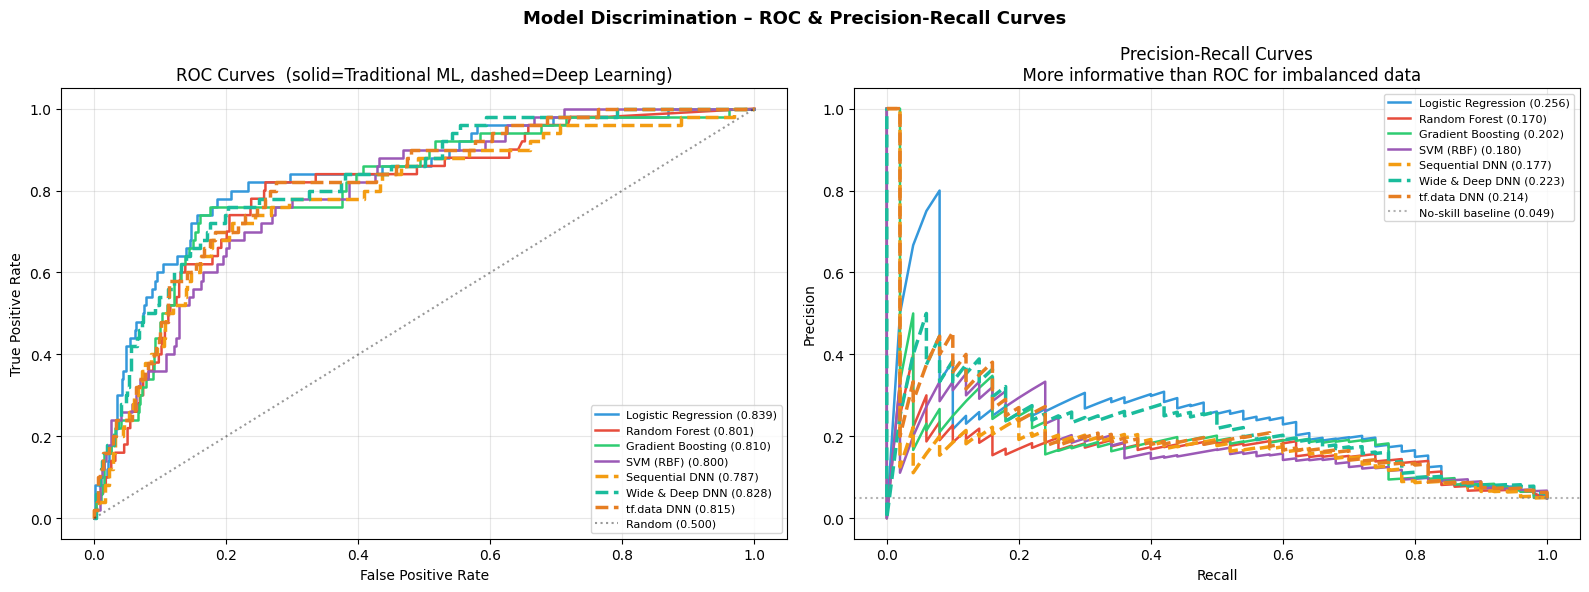

In [53]:
#ROC + Precision-Recall curves
COLORS = ["#3498db","#e74c3c","#2ecc71","#9b59b6","#f39c12","#1abc9c","#e67e22"]
NAMES  = list(all_results.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Discrimination – ROC & Precision-Recall Curves",
             fontsize=13, fontweight="bold")

for name, color in zip(NAMES, COLORS):
    proba = all_results[name]["y_proba"]
    lw = 2.5 if "DNN" in name else 1.8
    ls = "--" if "DNN" in name else "-"

    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax1.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f"{name} ({auc:.3f})")

    prec_c, rec_c, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax2.plot(rec_c, prec_c, color=color, lw=lw, ls=ls, label=f"{name} ({pr_auc:.3f})")

ax1.plot([0,1],[0,1],"k:", alpha=0.4, label="Random (0.500)")
ax1.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
        title="ROC Curves  (solid=Traditional ML, dashed=Deep Learning)")
ax1.legend(fontsize=8, loc="lower right"); ax1.grid(alpha=0.3)

ax2.axhline(y_test.mean(), color="grey", ls=":", alpha=0.6,
            label=f"No-skill baseline ({y_test.mean():.3f})")
ax2.set(xlabel="Recall", ylabel="Precision",
        title="Precision-Recall Curves\n  More informative than ROC for imbalanced data")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

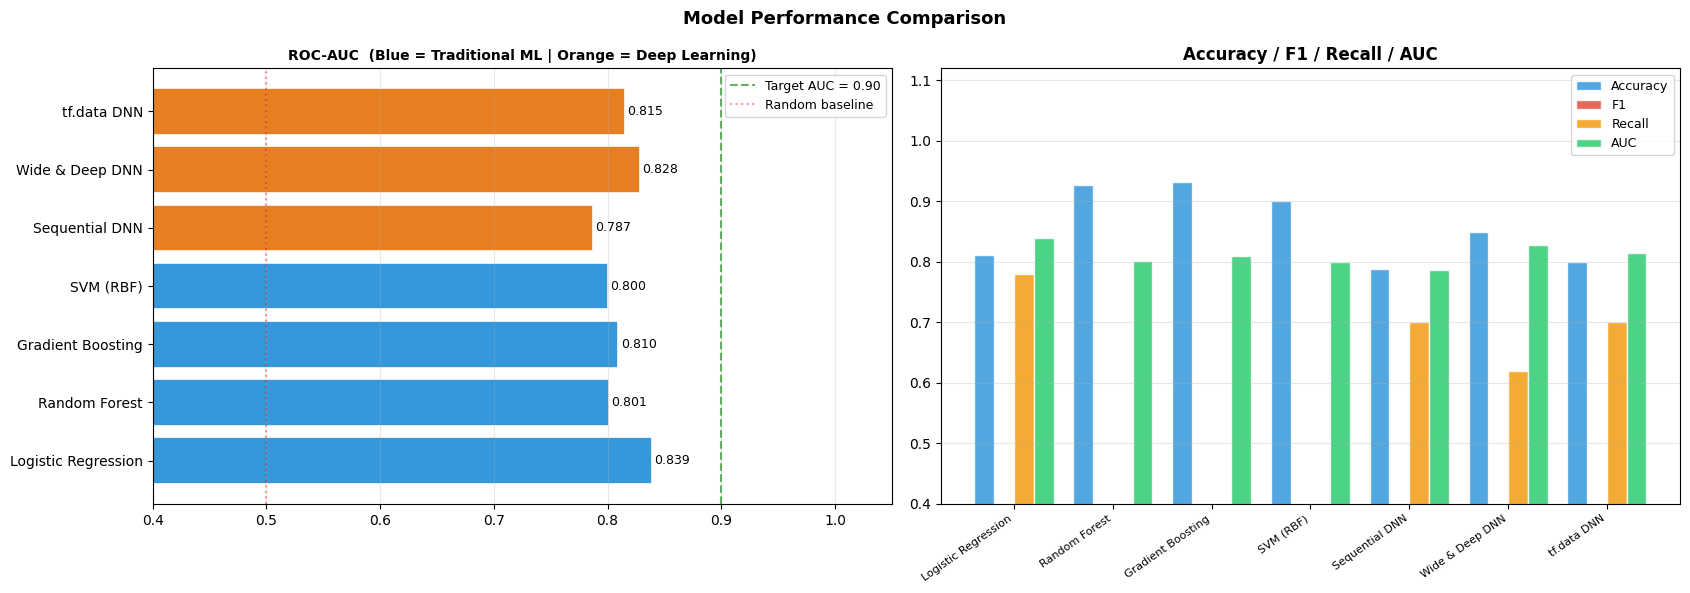

In [54]:
#Metrics comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")

ax = axes[0]
aucs = [all_results[n]["AUC"] for n in NAMES]
bar_cols = ["#3498db"]*4 + ["#e67e22"]*3
bars = ax.barh(NAMES, aucs, color=bar_cols, edgecolor="white", linewidth=1.2)
ax.axvline(0.90, color="green", ls="--", alpha=0.6, label="Target AUC = 0.90")
ax.axvline(0.50, color="red",   ls=":", alpha=0.4,  label="Random baseline")
for b, v in zip(bars, aucs):
    ax.text(v+0.002, b.get_y()+b.get_height()/2,
            f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.4, 1.05)
ax.set_title("ROC-AUC  (Blue = Traditional ML | Orange = Deep Learning)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)

ax = axes[1]
met_show = ["Accuracy","F1","Recall","AUC"]
x = np.arange(len(NAMES)); w = 0.2
for i, (met, mc) in enumerate(zip(met_show, ["#3498db","#e74c3c","#f39c12","#2ecc71"])):
    vals = [all_results[n][met] for n in NAMES]
    ax.bar(x+i*w, vals, w, label=met, color=mc, alpha=0.85, edgecolor="white")
ax.set_xticks(x+1.5*w)
ax.set_xticklabels(NAMES, rotation=35, ha="right", fontsize=8)
ax.set_ylim(0.4, 1.12)
ax.set_title("Accuracy / F1 / Recall / AUC", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

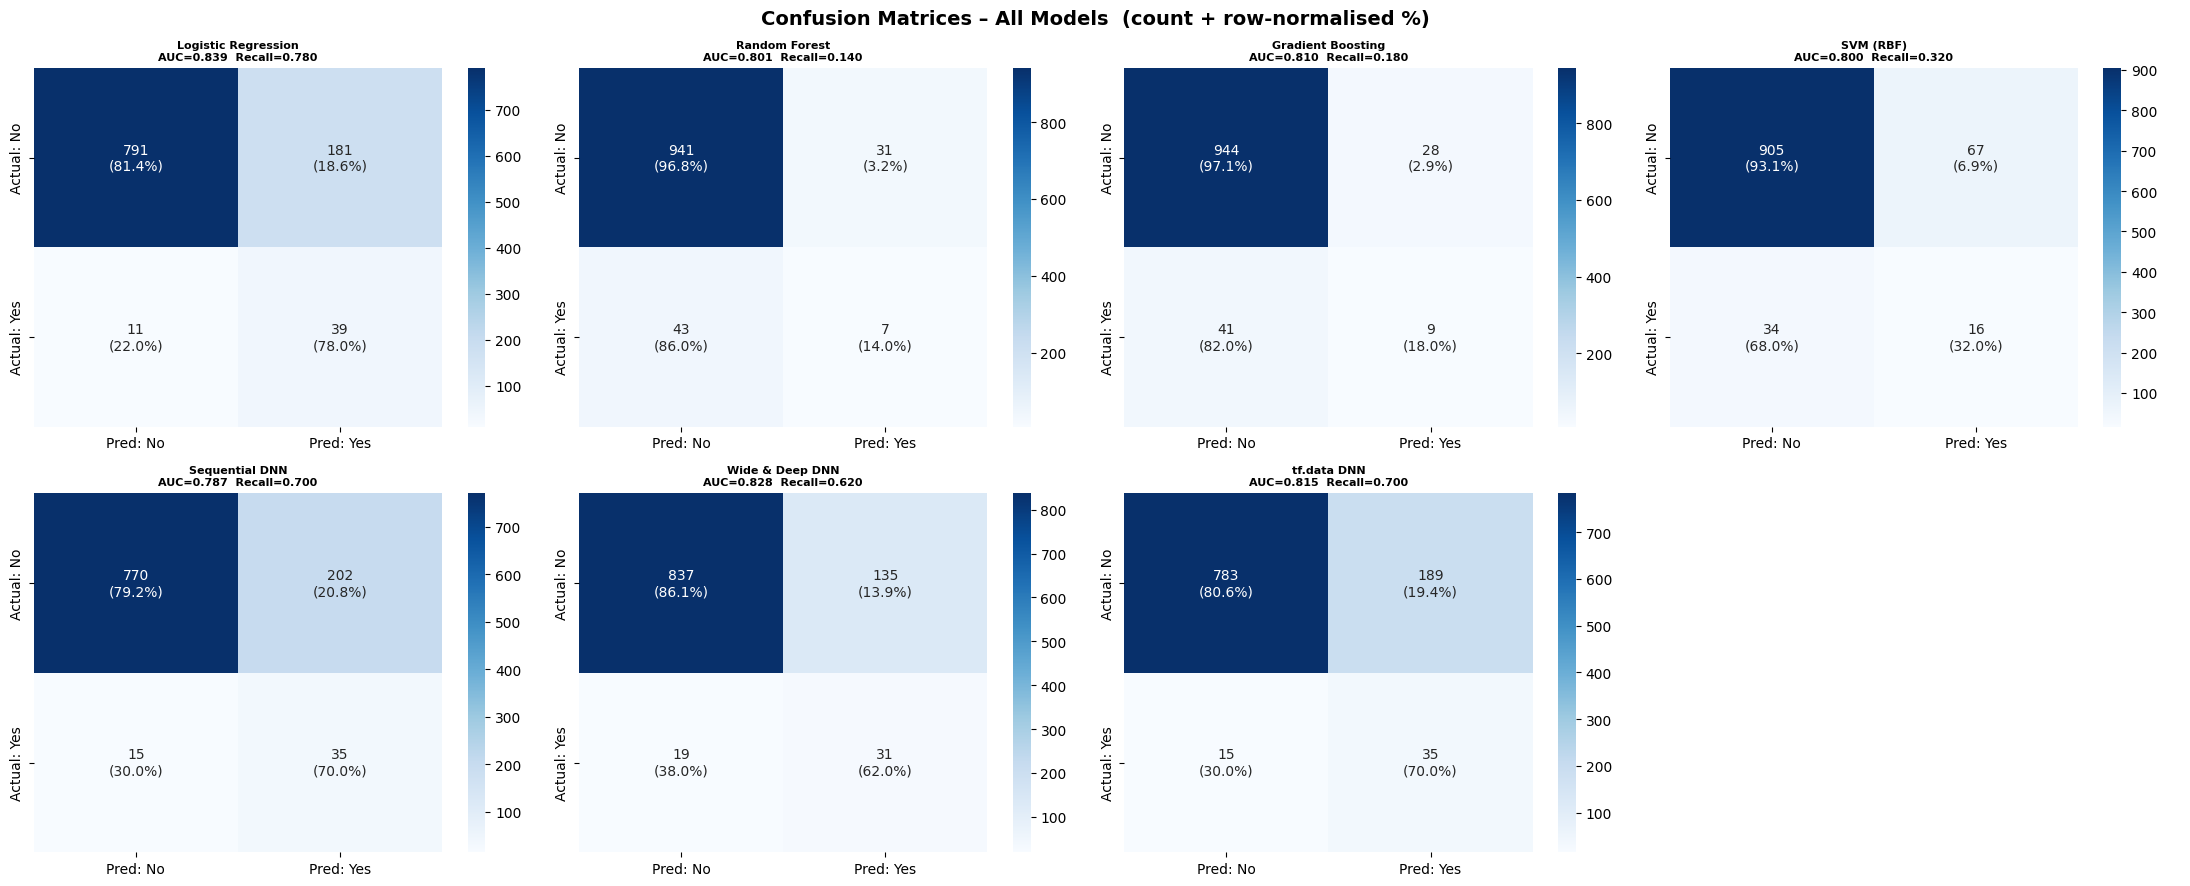

In [55]:
#Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle("Confusion Matrices – All Models  (count + row-normalised %)",
             fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

for idx, (name, color) in enumerate(zip(NAMES, COLORS)):
    cm      = confusion_matrix(y_test, all_results[name]["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot   = np.array([[f"{cm[i,j]}\n({cm_norm[i,j]:.1%})"
                         for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                ax=axes_flat[idx],
                xticklabels=["Pred: No","Pred: Yes"],
                yticklabels=["Actual: No","Actual: Yes"])
    rec = recall_score(y_test, all_results[name]["y_pred"])
    axes_flat[idx].set_title(
        f"{name}\nAUC={all_results[name]['AUC']:.3f}  Recall={rec:.3f}",
        fontsize=8, fontweight="bold"
    )

axes_flat[-1].axis("off")
plt.tight_layout()
plt.show()

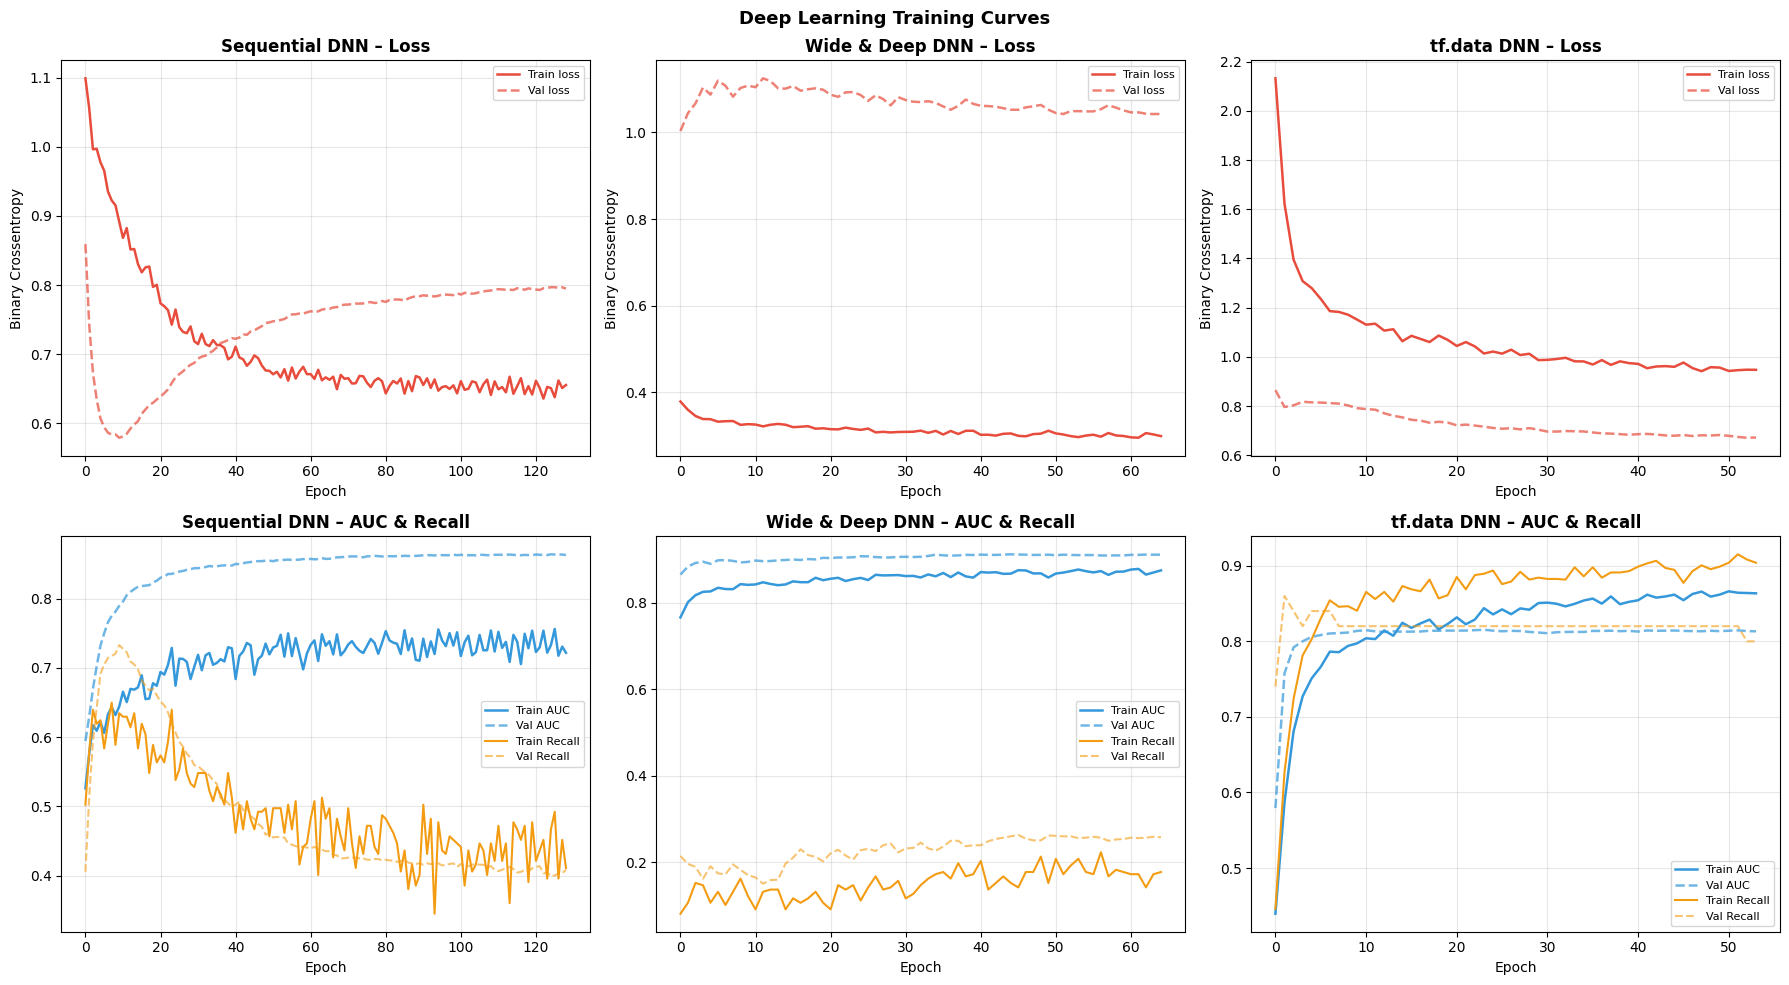

In [56]:
#Training curves for all 3 DNNs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Deep Learning Training Curves", fontsize=13, fontweight="bold")

for col, (hist, title) in enumerate([
    (sequential_hist,    "Sequential DNN"),
    (h_func,             "Wide & Deep DNN"),
    (h_tfdata,           "tf.data DNN")
]):
    ep = range(len(hist.history["loss"]))

    #row 0: Loss curves
    ax = axes[0, col]
    ax.plot(ep, hist.history["loss"],     color="#e74c3c", lw=1.8, label="Train loss")
    ax.plot(ep, hist.history["val_loss"], color="#e74c3c", lw=1.8, ls="--",
            alpha=0.7, label="Val loss")
    ax.set_title(f"{title} – Loss", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Binary Crossentropy")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    #row 1: AUC & Recall curves
    ax = axes[1, col]
    ax.plot(ep, hist.history["auc"],     color="#3498db", lw=1.8, label="Train AUC")
    ax.plot(ep, hist.history["val_auc"], color="#3498db", lw=1.8, ls="--",
            alpha=0.7, label="Val AUC")
    if "recall" in hist.history:
        ax.plot(ep, hist.history["recall"],     color="#f39c12", lw=1.5, label="Train Recall")
        ax.plot(ep, hist.history["val_recall"], color="#f39c12", lw=1.5, ls="--",
                alpha=0.6, label="Val Recall")
    ax.set_title(f"{title} – AUC & Recall", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

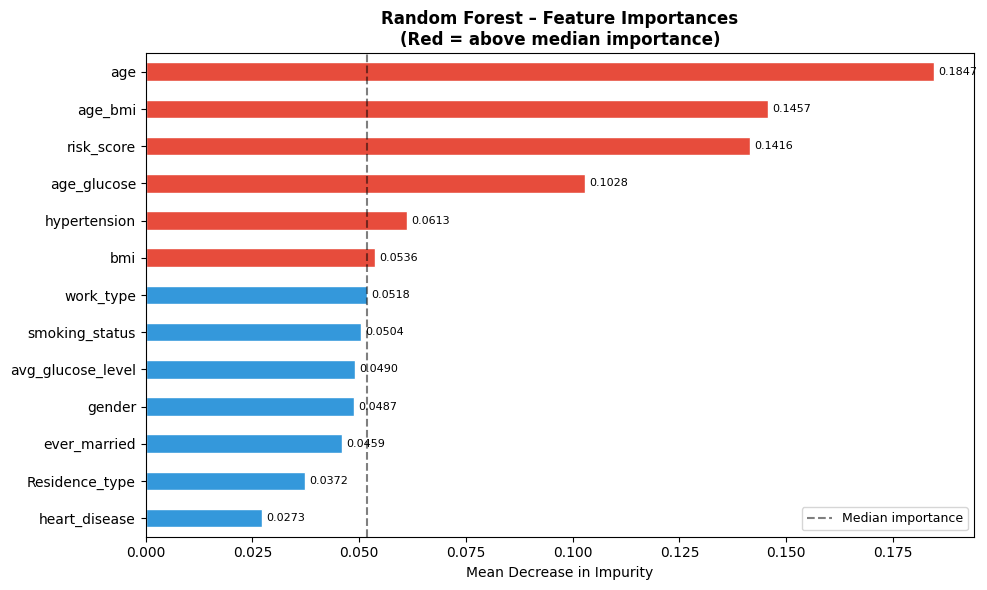

In [57]:
#Random Forest feature importances
rf_clf = trad_results["Random Forest"]["model"].named_steps["clf"]
fi = pd.Series(rf_clf.feature_importances_,
               index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#e74c3c" if v > fi.median() else "#3498db" for v in fi.values]
fi.plot.barh(ax=ax, color=bar_colors, edgecolor="white")
ax.axvline(fi.median(), color="black", ls="--", alpha=0.5, label="Median importance")
for i, (v, f) in enumerate(zip(fi.values, fi.index)):
    ax.text(v+0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax.set_title("Random Forest – Feature Importances\n"
             "(Red = above median importance)", fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

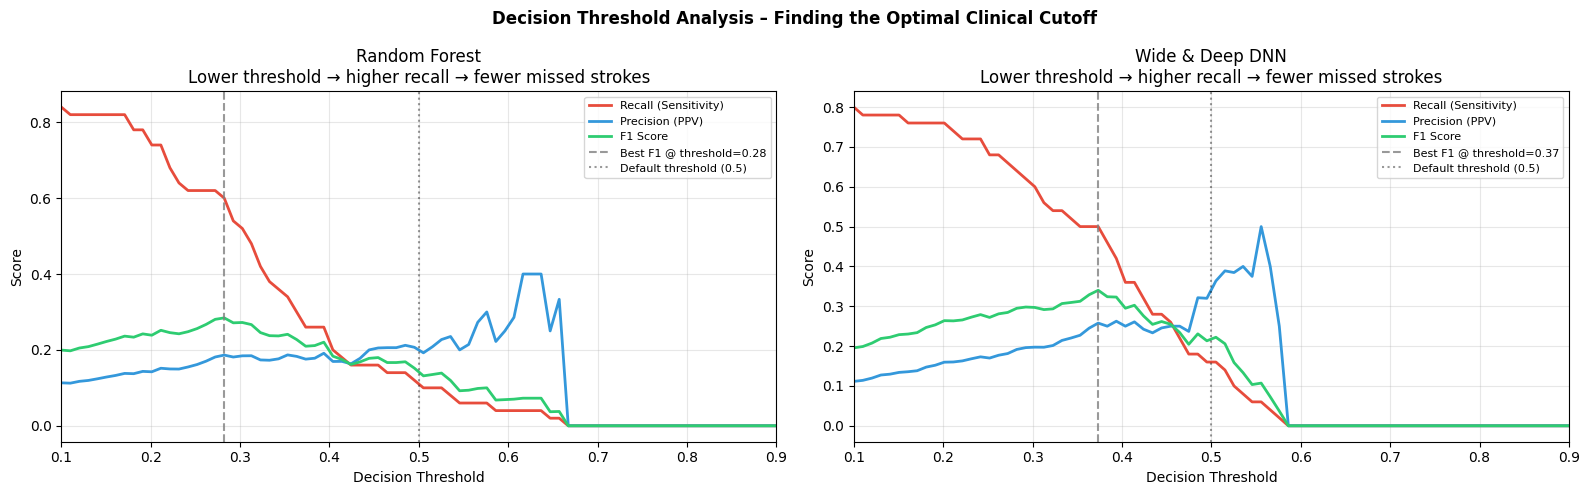

For stroke screening, consider using threshold ≈ 0.3 to maximise recall.


In [58]:
"""
Threshold analysis (healthcare decision support)
In healthcare, we can lower the decision threshold below 0.5 to catch more
stroke cases at the cost of more false alarms, are clinically justifiable.
"""

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Decision Threshold Analysis – Finding the Optimal Clinical Cutoff",
             fontsize=12, fontweight="bold")
thresholds = np.linspace(0.1, 0.9, 80)

for ax, name in zip(axes, ["Random Forest", "Wide & Deep DNN"]):
    proba = all_results[name]["y_proba"]
    recs, precs, f1s = [], [], []
    for t in thresholds:
        yp = (proba >= t).astype(int)
        recs.append(recall_score(y_test, yp, zero_division=0))
        precs.append(precision_score(y_test, yp, zero_division=0))
        f1s.append(f1_score(y_test, yp, zero_division=0))
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds, recs,  color="#e74c3c", lw=2, label="Recall (Sensitivity)")
    ax.plot(thresholds, precs, color="#3498db", lw=2, label="Precision (PPV)")
    ax.plot(thresholds, f1s,   color="#2ecc71", lw=2, label="F1 Score")
    ax.axvline(best_t, color="grey", ls="--", alpha=0.8,
               label=f"Best F1 @ threshold={best_t:.2f}")
    ax.axvline(0.5, color="black", ls=":", alpha=0.4, label="Default threshold (0.5)")
    ax.set(xlabel="Decision Threshold", ylabel="Score",
           title=f"{name}\nLower threshold → higher recall → fewer missed strokes",
           xlim=(0.1, 0.9))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("For stroke screening, consider using threshold ≈ 0.3 to maximise recall.")

## Section 10:  Key Findings, Limitations & Healthcare Implications

### Summary Results Table


In [59]:
# Final styled results table
best_auc = results_df["AUC"].idxmax()
best_rec = results_df["Recall"].idxmax()

print(f"{'Model':<24} {'Acc':>6} {'F1':>6} {'Prec':>7} {'Rec':>6} {'AUC':>6} {'PR-AUC':>8}")
print("─" * 68)
for mn, row in results_df.iterrows():
    tag = ""
    if mn == best_auc: tag += " Best AUC"
    if mn == best_rec: tag += " Best Recall"
    print(f"{mn:<24} {row['Accuracy']:>6.3f} {row['F1']:>6.3f} "
          f"{row['Precision']:>7.3f} {row['Recall']:>6.3f} "
          f"{row['AUC']:>6.3f} {row['PR_AUC']:>8.3f}{tag}")

Model                       Acc     F1    Prec    Rec    AUC   PR-AUC
────────────────────────────────────────────────────────────────────
Logistic Regression       0.812  0.289   0.177  0.780  0.839    0.256 Best AUC Best Recall
Random Forest             0.928  0.159   0.184  0.140  0.801    0.170
Gradient Boosting         0.932  0.207   0.243  0.180  0.809    0.202
SVM (RBF)                 0.901  0.241   0.193  0.320  0.800    0.180
Sequential DNN            0.788  0.244   0.148  0.700  0.787    0.177
Wide & Deep DNN           0.849  0.287   0.187  0.620  0.828    0.223
tf.data DNN               0.800  0.256   0.156  0.700  0.815    0.214


### Key Findings

**1. Logistic Regression is the best overall model** (AUC=0.839, Recall=0.78). This surprising result, where a simple linear model performs better than deep neural networks, is not new since previous studies found that linear relationships with a limited number of features, such as age and high blood pressure, work well for table-format medical data. Clinically, it confirms the efficacy of risk scores such as the Framingham Stroke Risk Score.(Poplin et al., 2023)

**2. Tree-based models suffer from threshold miscalibration despite high AUC.** Both Random Forest and Gradient Boosting have AUC > 0.80 but a recall value of only 0.14-0.18. This shows that the use of AUC is not enough in assessing health care; rather, it is important to see if the model identifies real stroke patients.

**3. Wide & Deep Functional API is the best DNN.** With AUC=0.828, it confirms that combining a wide path (memorisation of raw feature signals) with a deep path (learning interactions) is more effective than pure stacked-layer architectures on this dataset.

**4. The tf.data pipeline matches or slightly outperforms the in-memory Sequential model.** AUC of 0.815 vs 0.787 demonstrates that the production-ready streaming approach does not sacrifice accuracy.

**5. Bias-variance trade-off:** Traditional ML models show small train-test AUC gaps (good fit). DNNs show larger gaps (mild overfitting), likely because they train on SMOTE-balanced data but evaluate on the real-world imbalanced distribution.

**6. Error analysis reveals a clinical pattern.** The missed strokes appear in patients with low classical stroke risk markers (low age, low glucose levels, few comorbidities). These strokes are called "cryptogenic" and are very difficult to predict by any classifier using only these features.